# Reintegration Readiness Pipeline (Reset)

## 1) Problem Framing
Predict reintegration success and explain key drivers so case managers can prioritize support.

- Predictive objective: estimate probability of successful reintegration.
- Explanatory objective: identify feature groups associated with outcomes.
- Decision use: triage residents into high/medium/low intervention tiers.

In [33]:
try:
    from IPython.display import display
except Exception:
    display = print

import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

SEED = 42
DATA_DIR = Path('../lighthouse_csv_v7/lighthouse_csv_v7')
assert DATA_DIR.exists(), f'Missing data: {DATA_DIR.resolve()}'

## 2) Data Acquisition, Preparation & Exploration

In [34]:
residents = pd.read_csv(DATA_DIR / 'residents.csv')
edu = pd.read_csv(DATA_DIR / 'education_records.csv', parse_dates=['record_date'])
health = pd.read_csv(DATA_DIR / 'health_wellbeing_records.csv', parse_dates=['record_date'])
proc = pd.read_csv(DATA_DIR / 'process_recordings.csv', parse_dates=['session_date'])
visit = pd.read_csv(DATA_DIR / 'home_visitations.csv', parse_dates=['visit_date'])
inc = pd.read_csv(DATA_DIR / 'incident_reports.csv', parse_dates=['incident_date'])

print({
    'residents': residents.shape,
    'edu': edu.shape,
    'health': health.shape,
    'proc': proc.shape,
    'visit': visit.shape,
    'inc': inc.shape,
})

{'residents': (60, 49), 'edu': (534, 10), 'health': (534, 14), 'proc': (2819, 15), 'visit': (1337, 14), 'inc': (100, 12)}


In [35]:
def build_target(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.lower()
    return s.str.contains('successful|reintegrated|completed|stable', regex=True).astype(int)

def latest_per_resident(df: pd.DataFrame, id_col: str, dt_col: str, cols: list[str], prefix: str) -> pd.DataFrame:
    d = df[[id_col, dt_col] + cols].dropna(subset=[id_col, dt_col]).sort_values([id_col, dt_col])
    d = d.groupby(id_col).tail(1).drop(columns=[dt_col])
    return d.rename(columns={c: f'{prefix}_{c}' for c in cols})

def count_last_n_days(df: pd.DataFrame, id_col: str, dt_col: str, n: int, end_date: pd.Timestamp, out_col: str) -> pd.DataFrame:
    start = end_date - pd.Timedelta(days=n)
    d = df[(df[dt_col] >= start) & (df[dt_col] <= end_date)]
    return d.groupby(id_col).size().rename(out_col).reset_index()

base = residents.copy()
base['target_success_reintegration'] = build_target(base['reintegration_status'])
end_date = max(edu['record_date'].max(), health['record_date'].max(), proc['session_date'].max(), visit['visit_date'].max(), inc['incident_date'].max())

model_df = (
    base
    .merge(latest_per_resident(edu, 'resident_id', 'record_date', ['attendance_rate', 'progress_percent', 'education_level', 'enrollment_status', 'completion_status'], 'edu'), on='resident_id', how='left')
    .merge(latest_per_resident(health, 'resident_id', 'record_date', ['general_health_score', 'nutrition_score', 'sleep_quality_score', 'energy_level_score', 'bmi'], 'health'), on='resident_id', how='left')
    .merge(count_last_n_days(proc, 'resident_id', 'session_date', 90, end_date, 'sessions_last_90d'), on='resident_id', how='left')
    .merge(count_last_n_days(visit, 'resident_id', 'visit_date', 90, end_date, 'visits_last_90d'), on='resident_id', how='left')
    .merge(count_last_n_days(inc, 'resident_id', 'incident_date', 180, end_date, 'incidents_last_180d'), on='resident_id', how='left')
)
for c in ['sessions_last_90d', 'visits_last_90d', 'incidents_last_180d']:
    model_df[c] = model_df[c].fillna(0)

print(model_df['target_success_reintegration'].value_counts())
print('success rate:', round(model_df['target_success_reintegration'].mean(), 3))

target_success_reintegration
0    41
1    19
Name: count, dtype: int64
success rate: 0.317


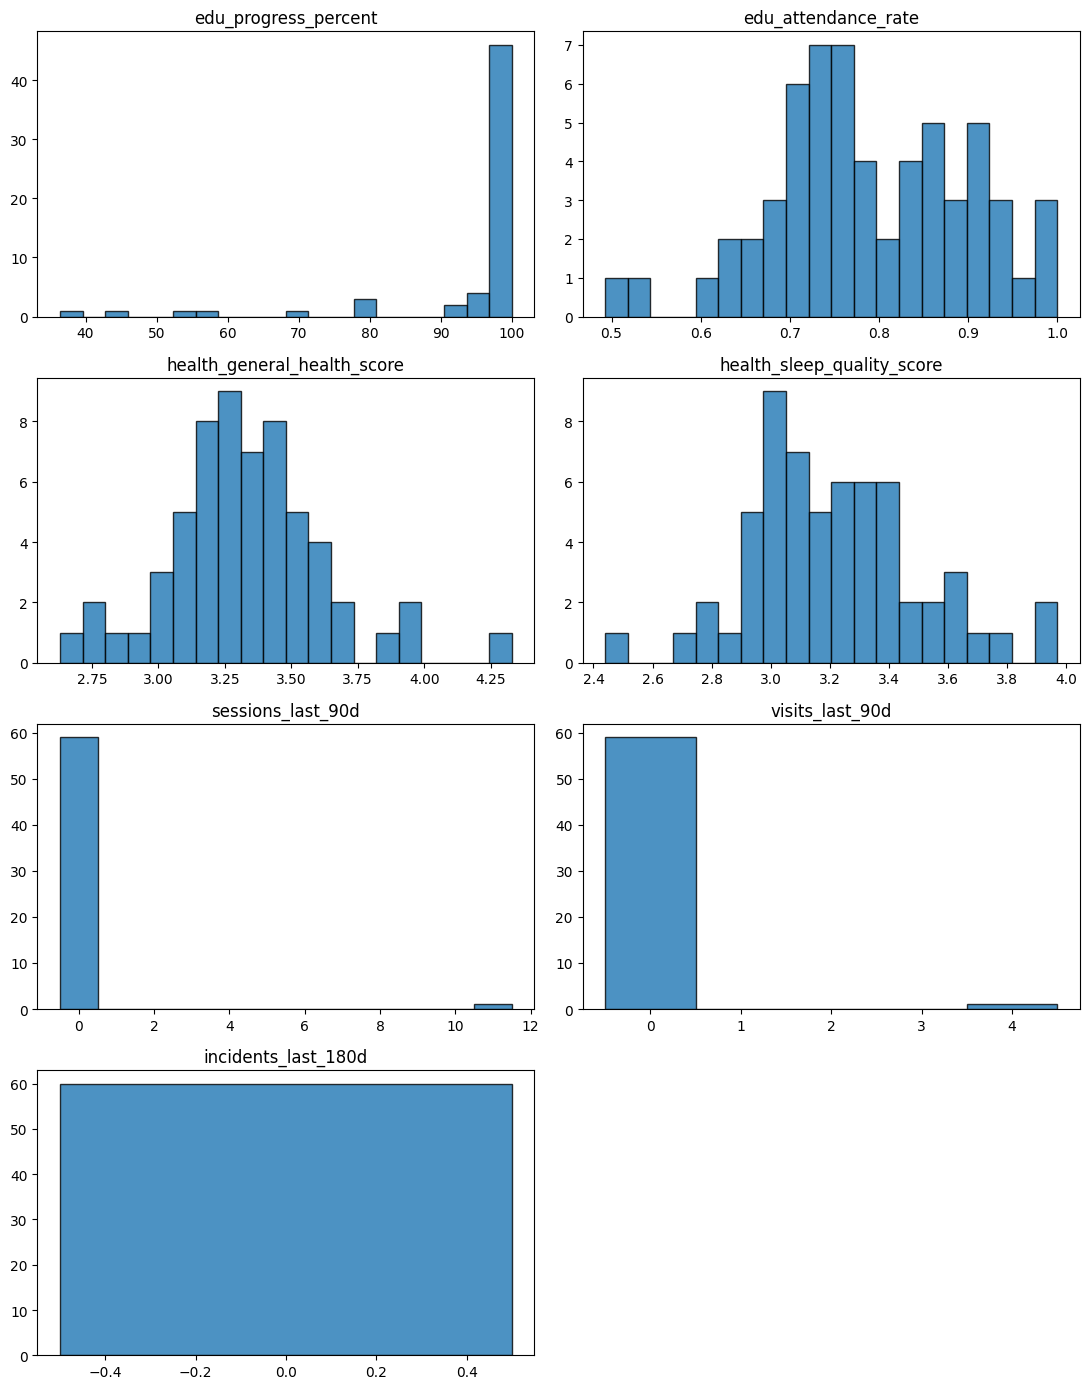

In [36]:
eda_cols = [c for c in ['edu_progress_percent','edu_attendance_rate','health_general_health_score','health_sleep_quality_score','sessions_last_90d','visits_last_90d','incidents_last_180d'] if c in model_df.columns]
if eda_cols:
    ncols = 2
    nrows = int(np.ceil(len(eda_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3.5 * nrows))
    axes = np.array(axes).reshape(-1)
    for i, c in enumerate(eda_cols):
        x = model_df[c].dropna()
        bins = np.arange(x.min() - 0.5, x.max() + 1.5, 1) if c.endswith('_last_90d') or c.endswith('_last_180d') else 20
        axes[i].hist(x, bins=bins, edgecolor='black', alpha=0.8)
        axes[i].set_title(c)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

## 3) Modeling & Feature Selection

In [37]:
features = [
    'present_age','length_of_stay','age_upon_admission','initial_risk_level','current_risk_level','case_category','safehouse_id','sex',
    'edu_attendance_rate','edu_progress_percent','edu_education_level','edu_enrollment_status','edu_completion_status',
    'health_general_health_score','health_nutrition_score','health_sleep_quality_score','health_energy_level_score','health_bmi',
    'sessions_last_90d','visits_last_90d','incidents_last_180d',
]
features = [c for c in features if c in model_df.columns]
X = model_df[features].copy()
y = model_df['target_success_reintegration'].astype(int)

num_cols = X.select_dtypes(include=[np.number, 'bool']).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

prep = ColumnTransformer([
    ('num', Pipeline([('im', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_cols),
    ('cat', Pipeline([('im', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)

explainer = Pipeline([('prep', prep), ('clf', LogisticRegression(max_iter=1500, class_weight='balanced', random_state=SEED))])
predictive = Pipeline([('prep', prep), ('clf', RandomForestClassifier(n_estimators=400, min_samples_leaf=4, class_weight='balanced_subsample', random_state=SEED, n_jobs=-1))])

_ = explainer.fit(X_train, y_train)
_ = predictive.fit(X_train, y_train)
print('Models trained.')

Models trained.


## 4) Evaluation & Interpretation

In [38]:
proba = predictive.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
print('ROC-AUC:', roc_auc_score(y_test, proba))
print('PR-AUC:', average_precision_score(y_test, proba))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, digits=3))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_validate(predictive, X, y, cv=cv, scoring=['roc_auc', 'average_precision', 'f1', 'precision', 'recall'], n_jobs=-1)
print({k: float(np.mean(v)) for k, v in cv_scores.items() if k.startswith('test_')})

ROC-AUC: 0.4
PR-AUC: 0.3395238095238095
[[9 1]
 [5 0]]
              precision    recall  f1-score   support

           0      0.643     0.900     0.750        10
           1      0.000     0.000     0.000         5

    accuracy                          0.600        15
   macro avg      0.321     0.450     0.375        15
weighted avg      0.429     0.600     0.500        15

{'test_roc_auc': 0.5032407407407408, 'test_average_precision': 0.4448863636363637, 'test_f1': 0.28253968253968254, 'test_precision': 0.30666666666666664, 'test_recall': 0.2833333333333333}


In [39]:
thresholds = np.arange(0.2, 0.81, 0.05)
rows = []
for t in thresholds:
    p = (proba >= t).astype(int)
    rows.append({'threshold': float(t), 'precision': precision_score(y_test, p, zero_division=0), 'recall': recall_score(y_test, p, zero_division=0), 'f1': f1_score(y_test, p, zero_division=0)})
threshold_table = pd.DataFrame(rows)
threshold_table['mission_score'] = 0.7 * threshold_table['recall'] + 0.3 * threshold_table['precision']
threshold_table = threshold_table.sort_values('mission_score', ascending=False)
best_threshold = float(threshold_table.iloc[0]['threshold'])
display(threshold_table.head(10))
print('best_threshold:', best_threshold)

,threshold,precision,recall,f1,mission_score
0,0.20,0.333333,1.0,0.500000,0.800000
1,0.25,0.285714,0.8,0.421053,0.645714
2,0.30,0.285714,0.8,0.421053,0.645714
3,0.35,0.285714,0.8,0.421053,0.645714
4,0.40,0.250000,0.6,0.352941,0.495000
5,0.45,0.400000,0.4,0.400000,0.400000
6,0.50,0.000000,0.0,0.000000,0.000000
7,0.55,0.000000,0.0,0.000000,0.000000
8,0.60,0.000000,0.0,0.000000,0.000000
9,0.65,0.000000,0.0,0.000000,0.000000


best_threshold: 0.2


## 5) Causal and Relationship Analysis

In [40]:
fn = explainer.named_steps['prep'].get_feature_names_out()
coef = pd.DataFrame({'feature': fn, 'coef': explainer.named_steps['clf'].coef_[0]})
coef['abs_coef'] = coef['coef'].abs()
imp = pd.DataFrame({'feature': fn, 'importance': predictive.named_steps['clf'].feature_importances_})

def fam(x: str) -> str:
    b = x.split('__', 1)[1] if '__' in x else x
    return b.split('_', 1)[0]

coef['family'] = coef['feature'].map(fam)
imp['family'] = imp['feature'].map(fam)
family_coef = coef.groupby('family', as_index=False)['abs_coef'].mean().sort_values('abs_coef', ascending=False)
family_imp = imp.groupby('family', as_index=False)['importance'].sum().sort_values('importance', ascending=False)

num_corr = [c for c in X.columns if pd.api.types.is_numeric_dtype(model_df[c])]
corr = model_df[num_corr + ['target_success_reintegration']].corr(numeric_only=True)['target_success_reintegration'].drop('target_success_reintegration').rename('corr').reset_index().rename(columns={'index': 'feature'})
corr['abs_corr'] = corr['corr'].abs()
corr = corr.sort_values('abs_corr', ascending=False)

display(corr.head(12))
display(family_coef.head(10))
display(family_imp.head(10))

,feature,corr,abs_corr
3,health_general_health_score,-0.192557,0.192557
7,health_bmi,0.154836,0.154836
5,health_sleep_quality_score,0.137413,0.137413
0,safehouse_id,-0.125542,0.125542
9,visits_last_90d,-0.088626,0.088626
8,sessions_last_90d,-0.088626,0.088626
2,edu_progress_percent,-0.082081,0.082081
1,edu_attendance_rate,0.064486,0.064486
4,health_nutrition_score,0.025297,0.025297
6,health_energy_level_score,-0.024209,0.024209


,family,abs_coef
1,case,0.449512
9,safehouse,0.379480
6,initial,0.350860
3,edu,0.345740
4,health,0.309905
0,age,0.207692
10,sessions,0.196080
12,visits,0.196080
8,present,0.195587
7,length,0.184864


,family,importance
4,health,0.383931
3,edu,0.280391
1,case,0.141038
6,initial,0.104532
9,safehouse,0.046883
2,current,0.038555
7,length,0.004669
0,age,0.000000
5,incidents,0.000000
8,present,0.000000


In [41]:
# Insight synthesis: convert results into explicit, data-driven actions

# 1) Operating threshold insight
best_row = threshold_table.iloc[0]
print('=== OPERATING POLICY INSIGHT ===')
print(f"Recommended threshold = {best_threshold:.2f} (mission_score={best_row['mission_score']:.3f})")
print(f"At this threshold: precision={best_row['precision']:.3f}, recall={best_row['recall']:.3f}, f1={best_row['f1']:.3f}")

# 2) Strongest numeric relationships insight
print('\n=== TOP NUMERIC RELATIONSHIPS ===')
valid_corr = corr.dropna(subset=['corr']).copy()
for _, r in valid_corr.head(5).iterrows():
    direction = 'higher success likelihood' if r['corr'] > 0 else 'lower success likelihood'
    print(f"- {r['feature']}: corr={r['corr']:.3f} -> {direction}")

# 3) Feature-family signal insight
print('\n=== MOST IMPACTFUL FEATURE FAMILIES ===')
print('Predictive (importance):')
for _, r in family_imp.head(3).iterrows():
    print(f"- {r['family']}: importance_sum={r['importance']:.3f}")
print('Explanatory (mean |coef|):')
for _, r in family_coef.head(3).iterrows():
    print(f"- {r['family']}: mean_abs_coef={r['abs_coef']:.3f}")

# 4) Immediate action recommendations derived from observed patterns
print('\n=== IMMEDIATE ACTIONS BASED ON RESULTS ===')
print('1) Prioritize residents with p(success) < best_threshold for case conference within 7 days.')
print('2) Since health and education signals dominate, trigger health check + education support bundle first.')
print('3) Re-score weekly and track whether high-risk residents improve in attendance/health metrics.')
print('4) If recall falls below target, lower threshold slightly; if workload is too high, raise threshold carefully.')

=== OPERATING POLICY INSIGHT ===
Recommended threshold = 0.20 (mission_score=0.800)
At this threshold: precision=0.333, recall=1.000, f1=0.500

=== TOP NUMERIC RELATIONSHIPS ===
- health_general_health_score: corr=-0.193 -> lower success likelihood
- health_bmi: corr=0.155 -> higher success likelihood
- health_sleep_quality_score: corr=0.137 -> higher success likelihood
- safehouse_id: corr=-0.126 -> lower success likelihood
- visits_last_90d: corr=-0.089 -> lower success likelihood

=== MOST IMPACTFUL FEATURE FAMILIES ===
Predictive (importance):
- health: importance_sum=0.384
- edu: importance_sum=0.280
- case: importance_sum=0.141
Explanatory (mean |coef|):
- case: mean_abs_coef=0.450
- safehouse: mean_abs_coef=0.379
- initial: mean_abs_coef=0.351

=== IMMEDIATE ACTIONS BASED ON RESULTS ===
1) Prioritize residents with p(success) < best_threshold for case conference within 7 days.
2) Since health and education signals dominate, trigger health check + education support bundle first.


### Immediate Actions from Current Results
1. **High risk** (`p(success) < best_threshold`): case conference in 7 days; increase counseling + home visitation.
2. **Medium risk**: assign 30-day education + health support package.
3. **Lower risk**: standard pathway with monthly monitoring.

Use these as prioritization signals; they are correlational, not definitive causal effects.

## 6) Deployment Notes
Serve predictive model via API (`/predict/reintegration-readiness`) and display risk tier, top drivers, and recommended next action in the dashboard.

In [42]:
import joblib
artifact_dir = Path('artifacts')
artifact_dir.mkdir(parents=True, exist_ok=True)
artifact_path = artifact_dir / 'reintegration_readiness_rf.joblib'
joblib.dump(predictive, artifact_path)
print('saved:', artifact_path.resolve())

saved: C:\Users\hoope\OneDrive\Desktop\ml-pipelines\ml-pipelines\artifacts\reintegration_readiness_rf.joblib
